# 따릉이 거치대 수량(Available) 예측 — ML Pipeline

## 1. 라이브러리 로드 및 설정

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor

try:
    import xgboost as xgb
    HAS_XGB = True
    print("XGBoost loaded successfully")
except ImportError:
    HAS_XGB = False
    print("[Warning] XGBoost not found -> pip install xgboost")

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.family"] = "DejaVu Sans"

XGBoost loaded successfully


In [2]:
# pip install pmdarima nbformat

## 2. 설정값 및 데이터 로드

In [3]:
# 디렉토리 설정
import os
print(os.getcwd())
os.chdir("/Users/minseoksong/Desktop/Academics/Courses/Time Series Analysis and Lab/Project/2026-Spring-TimeSeries-Group2/99_bicycle-demand-forecase")
print(os.getcwd())

/Users/minseoksong/Desktop/Academics/Courses/Time Series Analysis and Lab/Project/2026-Spring-TimeSeries-Group2/99_bicycle-demand-forecase/notebooks
/Users/minseoksong/Desktop/Academics/Courses/Time Series Analysis and Lab/Project/2026-Spring-TimeSeries-Group2/99_bicycle-demand-forecase


In [4]:
# 설정값
DATA_DIR        = Path("data")   # interpolated_available_YYYYMM.csv
SEASONAL_PERIOD = 24             # 일일 계절 주기 (시간 단위 → S=24)
TEST_DAYS       = 30             # 마지막 30일을 test set으로 사용
TARGET_RENT_ID  = 2128           # 분석할 정류소 ID (정수형)
ALPHA = 0.5                      # Underestimate penalty rate - Overestimate가 거치대 잔여 수량에 대해서는 더욱 치명적이다.


In [5]:
def load_available_csvs(data_dir: Path) -> pd.DataFrame:
    files = sorted(data_dir.glob("interpolated_available_*.csv"))
    if not files:
        raise FileNotFoundError(f"interpolated_available_*.csv 파일이 없습니다: {data_dir}")
    parts = [pd.read_csv(f) for f in files]
    df = pd.concat(parts, ignore_index=True)
    df["datetime"] = pd.to_datetime(
        df["DATE"].astype(str) + df["TIME"].astype(str).str.zfill(2),
        format="%Y%m%d%H"
    )
    df["RENT_ID"] = df["RENT_ID"].astype(int)
    return df

df_raw = load_available_csvs(DATA_DIR)
print(f"전체 데이터: {df_raw.shape}")
print(f"날짜 범위: {df_raw['datetime'].min()} ~ {df_raw['datetime'].max()}")
print(f"정류소 수: {df_raw['RENT_ID'].nunique()}개")
print(f"정류소 목록: {sorted(df_raw['RENT_ID'].unique())}")
df_raw.head()


전체 데이터: (381432, 5)
날짜 범위: 2023-01-01 00:00:00 ~ 2024-12-31 23:00:00
정류소 수: 23개
정류소 목록: [np.int64(2111), np.int64(2112), np.int64(2116), np.int64(2122), np.int64(2128), np.int64(2129), np.int64(2130), np.int64(2139), np.int64(2143), np.int64(2148), np.int64(2159), np.int64(2171), np.int64(2172), np.int64(2178), np.int64(2179), np.int64(2185), np.int64(2186), np.int64(2191), np.int64(2198), np.int64(2199), np.int64(3310), np.int64(3311), np.int64(3802)]


,DATE,TIME,RENT_ID,AVAILABLE,datetime
0,20230101,0,2111,0,2023-01-01
1,20230101,0,2112,5,2023-01-01
2,20230101,0,2116,2,2023-01-01
3,20230101,0,2122,1,2023-01-01
4,20230101,0,2128,5,2023-01-01


## 3. 데이터 전처리
`interpolated_available_YYYYMM.csv`는 이미 보간 완료된 데이터입니다.
- 결측치 없음 (선형 보간 적용 완료)
- 타겟 변수: `AVAILABLE` (시간대별 거치대 잔여 수량)
- 데이터 기간: 2023-01-01 ~ 2024-12-31
- 보간 전처리 관련은 `interpolation_available_report.md` 참고

In [6]:
def make_series(df: pd.DataFrame, rent_id: int) -> pd.Series:
    """
    특정 정류소의 시간별 AVAILABLE 시계열 생성
    interpolated_available_*.csv는 이미 보간 완료 → 결측 없음
    """
    sub = (
        df[df["RENT_ID"] == rent_id]
        .set_index("datetime")["AVAILABLE"]
        .sort_index()
    )
    full_idx = pd.date_range(sub.index.min(), sub.index.max(), freq="h")
    sub = sub.reindex(full_idx)
    return sub.astype(float)

series = make_series(df_raw, TARGET_RENT_ID)
print(f"정류소 {TARGET_RENT_ID} 시계열: {len(series):,}시간")
print(f"기간: {series.index[0]} ~ {series.index[-1]}")
print(f"결측 수: {series.isna().sum()}")
series.head(10)


정류소 2128 시계열: 17,544시간
기간: 2023-01-01 00:00:00 ~ 2024-12-31 23:00:00
결측 수: 960


2023-01-01 00:00:00    5.0
2023-01-01 01:00:00    4.0
2023-01-01 02:00:00    4.0
2023-01-01 03:00:00    4.0
2023-01-01 04:00:00    4.0
2023-01-01 05:00:00    4.0
2023-01-01 06:00:00    6.0
2023-01-01 07:00:00    6.0
2023-01-01 08:00:00    5.0
2023-01-01 09:00:00    5.0
Freq: h, Name: AVAILABLE, dtype: float64

In [7]:
from src.utils import load_rainfall_binary, make_features_rainfall_binary, evaluate_ml_forecast
weather_df = load_rainfall_binary(DATA_DIR)

print(f"Station {TARGET_RENT_ID} — {len(series):,} hours")
print(f"Weather — {len(weather_df):,} hours")

Station 2128 — 17,544 hours
Weather — 43,824 hours


In [8]:
weather_df.head(5)

,temp,rain_binary
datetime,,
2021-01-01 00:00:00,-8.3,0
2021-01-01 01:00:00,-8.7,0
2021-01-01 02:00:00,-9.1,0
2021-01-01 03:00:00,-9.3,0
2021-01-01 04:00:00,-9.3,0


In [9]:
weather_df[weather_df["rain_binary"] != 0].head(5)

,temp,rain_binary
datetime,,
2021-01-06 21:00:00,-5.1,1
2021-01-12 18:00:00,-0.8,1
2021-01-21 18:00:00,4.6,1
2021-01-21 19:00:00,4.6,1
2021-01-21 20:00:00,4.6,1


In [10]:
df_feat = make_features_rainfall_binary(series, weather_df)
print(f"Feature matrix: {df_feat.shape}")
print(f"Features: {[c for c in df_feat.columns if c != 'CNT']}")
df_feat.head()


Feature matrix: (15576, 12)
Features: ['hour', 'dayofweek', 'month', 'is_weekend', 'lag_1', 'lag_24', 'lag_168', 'rolling_mean_24', 'rolling_mean_168', 'temp', 'rain_binary']


,CNT,hour,dayofweek,month,is_weekend,lag_1,lag_24,lag_168,rolling_mean_24,rolling_mean_168,temp,rain_binary
2023-01-08 00:00:00,0.0,0,6,1,1,0.0,1.0,5.0,1.000000,1.976190,-1.4,0
2023-01-08 01:00:00,0.0,1,6,1,1,0.0,0.0,4.0,0.958333,1.946429,-1.8,0
2023-01-08 02:00:00,0.0,2,6,1,1,0.0,0.0,4.0,0.958333,1.922619,-2.0,0
2023-01-08 03:00:00,1.0,3,6,1,1,0.0,1.0,4.0,0.958333,1.898810,-2.4,0
2023-01-08 04:00:00,0.0,4,6,1,1,1.0,1.0,4.0,0.958333,1.880952,-2.8,0


## 4. Train / Test Split

In [11]:
test_hours = TEST_DAYS * 24
train_df = df_feat.iloc[:-test_hours]
test_df  = df_feat.iloc[-test_hours:]

FEATURE_COLS = [c for c in df_feat.columns if c != "CNT"]

X_train = train_df[FEATURE_COLS]
y_train = train_df["CNT"]
X_test  = test_df[FEATURE_COLS]
y_test  = test_df["CNT"]

print(f"Train: {train_df.index[0]} ~ {train_df.index[-1]} ({len(train_df):,} rows)")
print(f"Test : {test_df.index[0]} ~ {test_df.index[-1]} ({len(test_df):,} rows)")
print(f"Features: {FEATURE_COLS}")


Train: 2023-01-08 00:00:00 ~ 2024-12-01 23:00:00 (14,856 rows)
Test : 2024-12-02 00:00:00 ~ 2024-12-31 23:00:00 (720 rows)
Features: ['hour', 'dayofweek', 'month', 'is_weekend', 'lag_1', 'lag_24', 'lag_168', 'rolling_mean_24', 'rolling_mean_168', 'temp', 'rain_binary']


## 6. Random Forest

Random Forest fitting complete

Feature Importances:
lag_1               0.917235
temp                0.016065
hour                0.015895
rolling_mean_24     0.015652
rolling_mean_168    0.014067
lag_168             0.005274
lag_24              0.005151
month               0.004913
dayofweek           0.004861
is_weekend          0.000767
rain_binary         0.000120


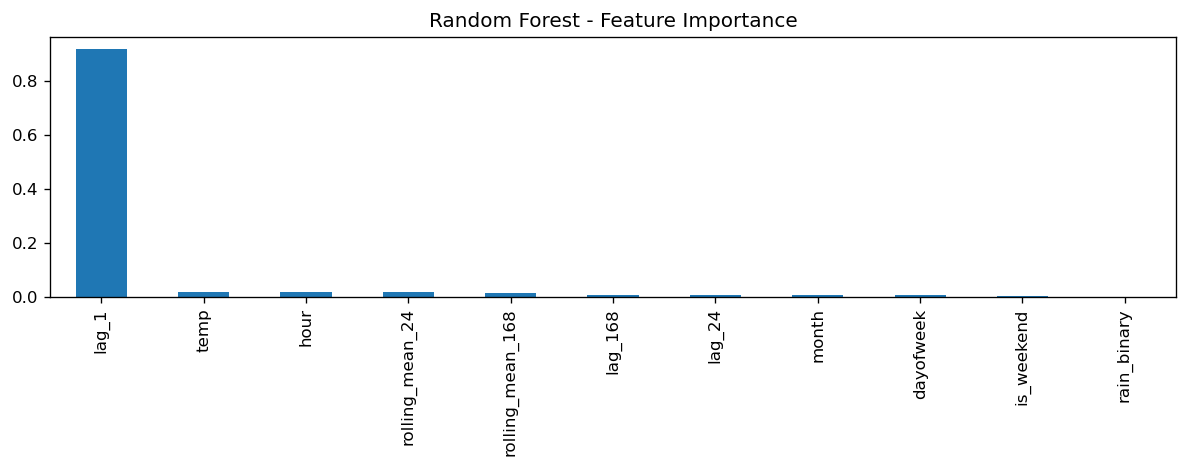

In [12]:
# Random Forest fitting
rf_model = RandomForestRegressor(
    n_estimators=200,     # 트리 개수
    max_depth=10,         # 트리 최대 깊이
    min_samples_leaf=5,   # 리프 노드 최소 샘플 수
    n_jobs=-1,            # 병렬 처리
    random_state=42,
)
rf_model.fit(X_train, y_train)
print("Random Forest fitting complete")

# Feature importance
importances = pd.Series(rf_model.feature_importances_, index=FEATURE_COLS)
importances = importances.sort_values(ascending=False)
print("\nFeature Importances:")
print(importances.to_string())

# Plot feature importance
importances.plot(kind="bar", figsize=(10, 4),
                 title="Random Forest - Feature Importance")
plt.tight_layout()
plt.show()

[Random Forest]
  RMSE            : 0.779
  MAE             : 0.544
  Asymmetric RMSE : 0.664  (alpha=0.5)
  Under-pred rate : 46.8%
  Over-pred rate : 53.2%


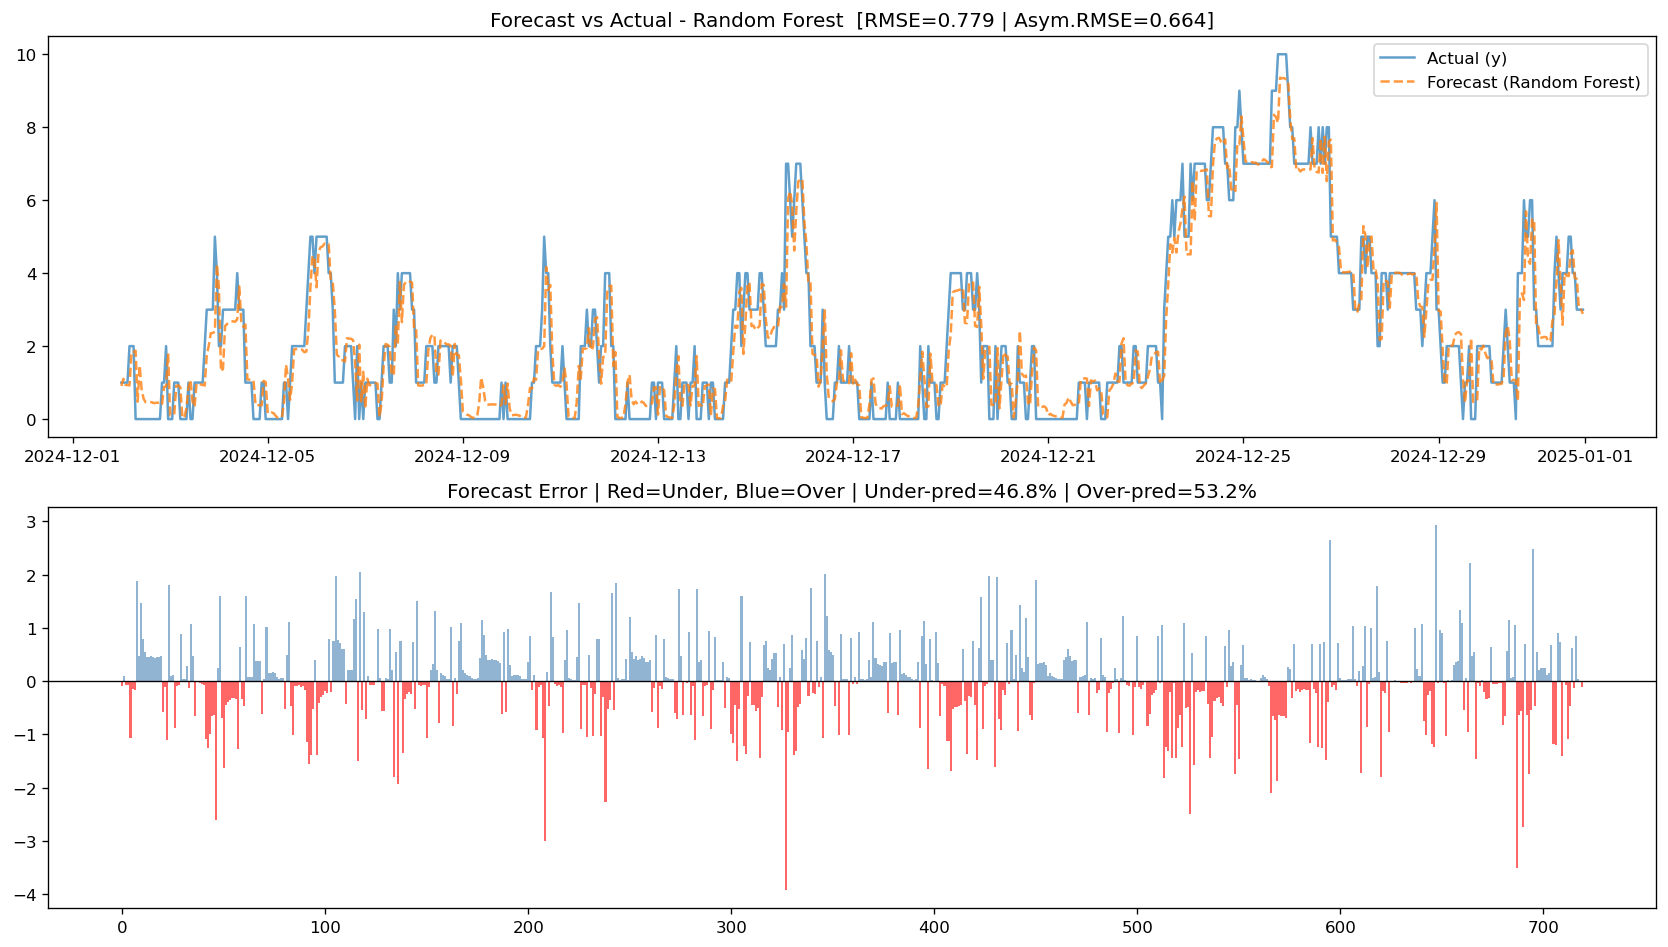

In [13]:
# Random Forest forecast evaluation
y_pred_rf = rf_model.predict(X_test)
perf_rf   = evaluate_ml_forecast(y_test, y_pred_rf,
                                  model_name="Random Forest", alpha=ALPHA)

## 7. XGBoost

XGBoost fitting complete

Feature Importances:
lag_1               0.781482
rolling_mean_24     0.056637
lag_24              0.026710
rain_binary         0.023002
is_weekend          0.018291
hour                0.017591
rolling_mean_168    0.016703
month               0.015915
dayofweek           0.015605
temp                0.015233
lag_168             0.012831


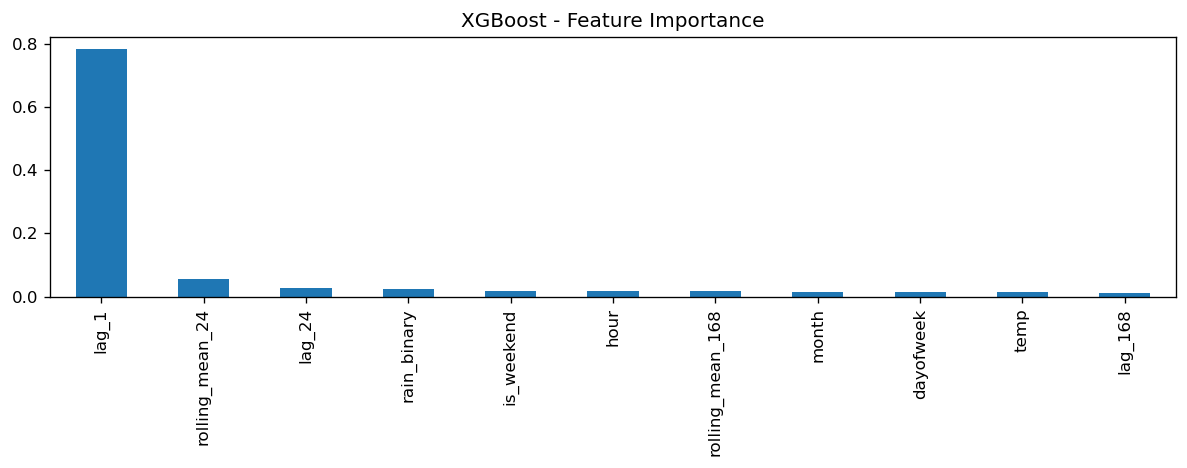

In [14]:
if HAS_XGB:
    xgb_model = xgb.XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
    )
    xgb_model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False,
    )
    print("XGBoost fitting complete")

    # Feature importance
    xgb_imp = pd.Series(xgb_model.feature_importances_, index=FEATURE_COLS)
    xgb_imp = xgb_imp.sort_values(ascending=False)
    print("\nFeature Importances:")
    print(xgb_imp.to_string())

    xgb_imp.plot(kind="bar", figsize=(10, 4),
                 title="XGBoost - Feature Importance")
    plt.tight_layout()
    plt.show()
else:
    print("XGBoost not installed. pip install xgboost")

[XGBoost]
  RMSE            : 0.818
  MAE             : 0.595
  Asymmetric RMSE : 0.682  (alpha=0.5)
  Under-pred rate : 51.8%
  Over-pred rate : 48.2%


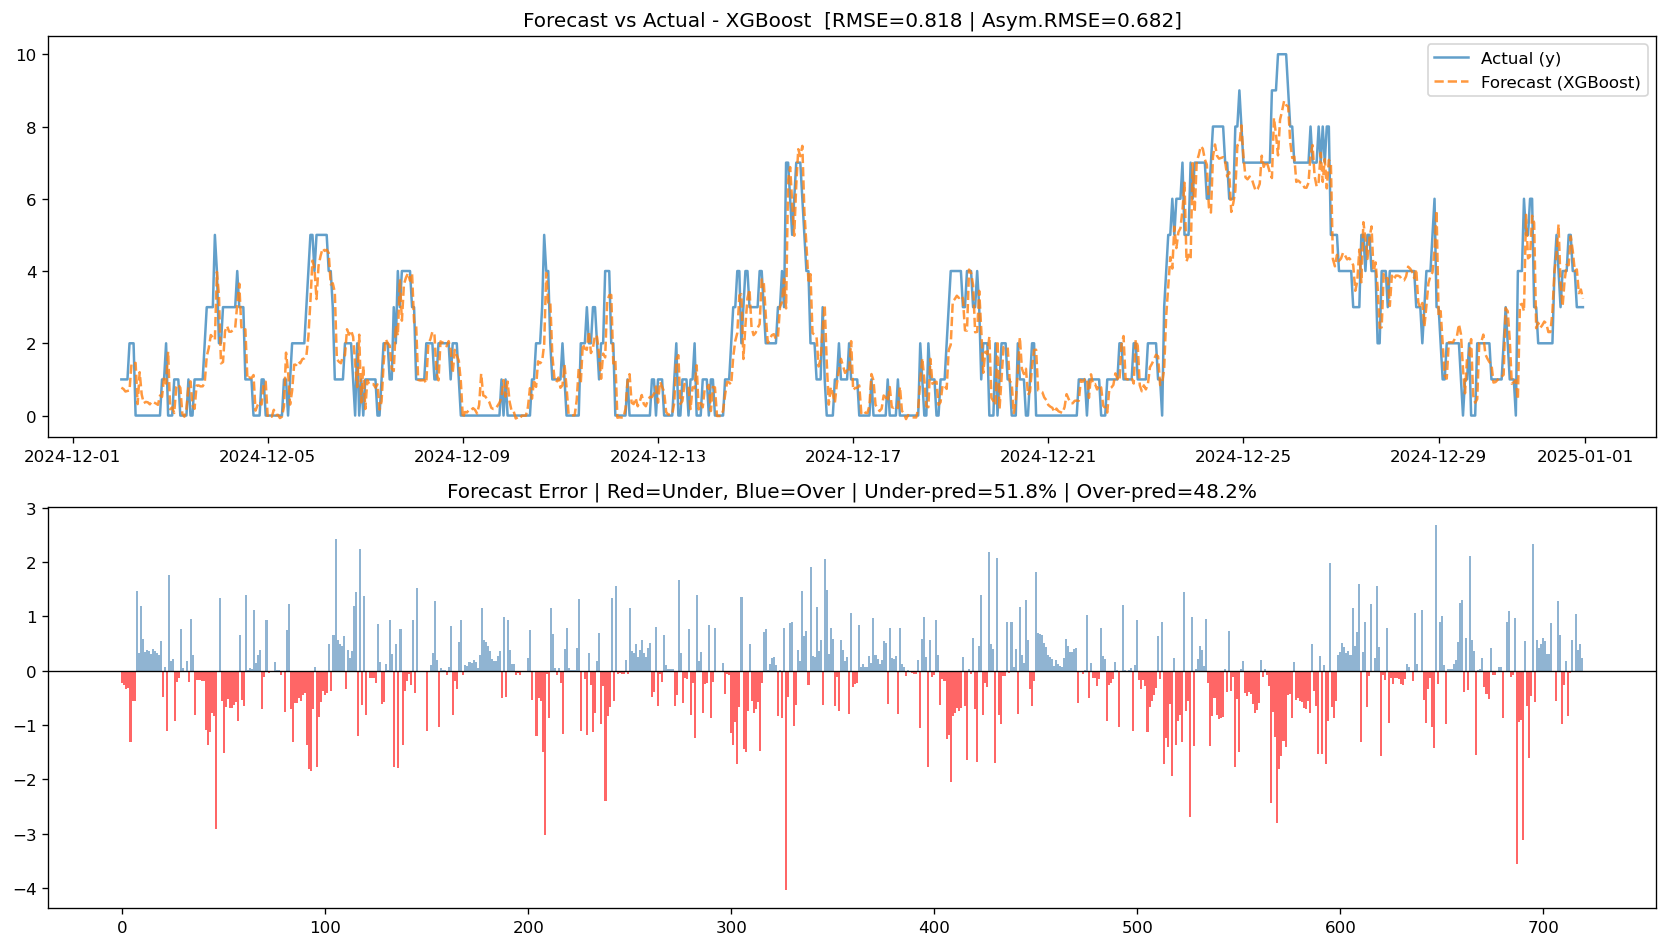

In [15]:
if HAS_XGB:
    y_pred_xgb = xgb_model.predict(X_test)
    perf_xgb   = evaluate_ml_forecast(y_test, y_pred_xgb,
                                       model_name="XGBoost", alpha=ALPHA)


In [16]:
# ── XGBoost with Asymmetric Loss Function ────────────────────
def asymmetric_obj(y_pred, dtrain, alpha=2.0):
    """
    Custom asymmetric loss for XGBoost (gradient & hessian).
    Under-prediction (y_pred < y_true): alpha * 2 * error
    Over-prediction  (y_pred >= y_true): 2 * error
    """
    y_true = dtrain.get_label()
    errors = y_pred - y_true

    grad = np.where(errors < 0,
                    alpha * 2 * errors,
                    2 * errors)
    hess = np.where(errors < 0,
                    alpha * 2 * np.ones_like(errors),
                    2 * np.ones_like(errors))
    return grad, hess

if HAS_XGB:
    dtrain = xgb.DMatrix(X_train, label=y_train)
    dtest  = xgb.DMatrix(X_test,  label=y_test)

    params = {
        "max_depth":        6,
        "learning_rate":    0.05,
        "subsample":        0.8,
        "colsample_bytree": 0.8,
        "seed":             42,
    }

    xgb_asym_model = xgb.train(
        params=params,
        dtrain=dtrain,
        num_boost_round=300,
        obj=lambda y_pred, dtrain: asymmetric_obj(y_pred, dtrain, alpha=ALPHA),
        evals=[(dtest, "test")],
        verbose_eval=False,
    )
    print("XGBoost (Asymmetric Loss) fitting complete")

XGBoost (Asymmetric Loss) fitting complete


[XGBoost (alpha=0.5)]
  RMSE            : 0.849
  MAE             : 0.609
  Asymmetric RMSE : 0.671  (alpha=0.5)
  Under-pred rate : 59.2%
  Over-pred rate : 40.8%


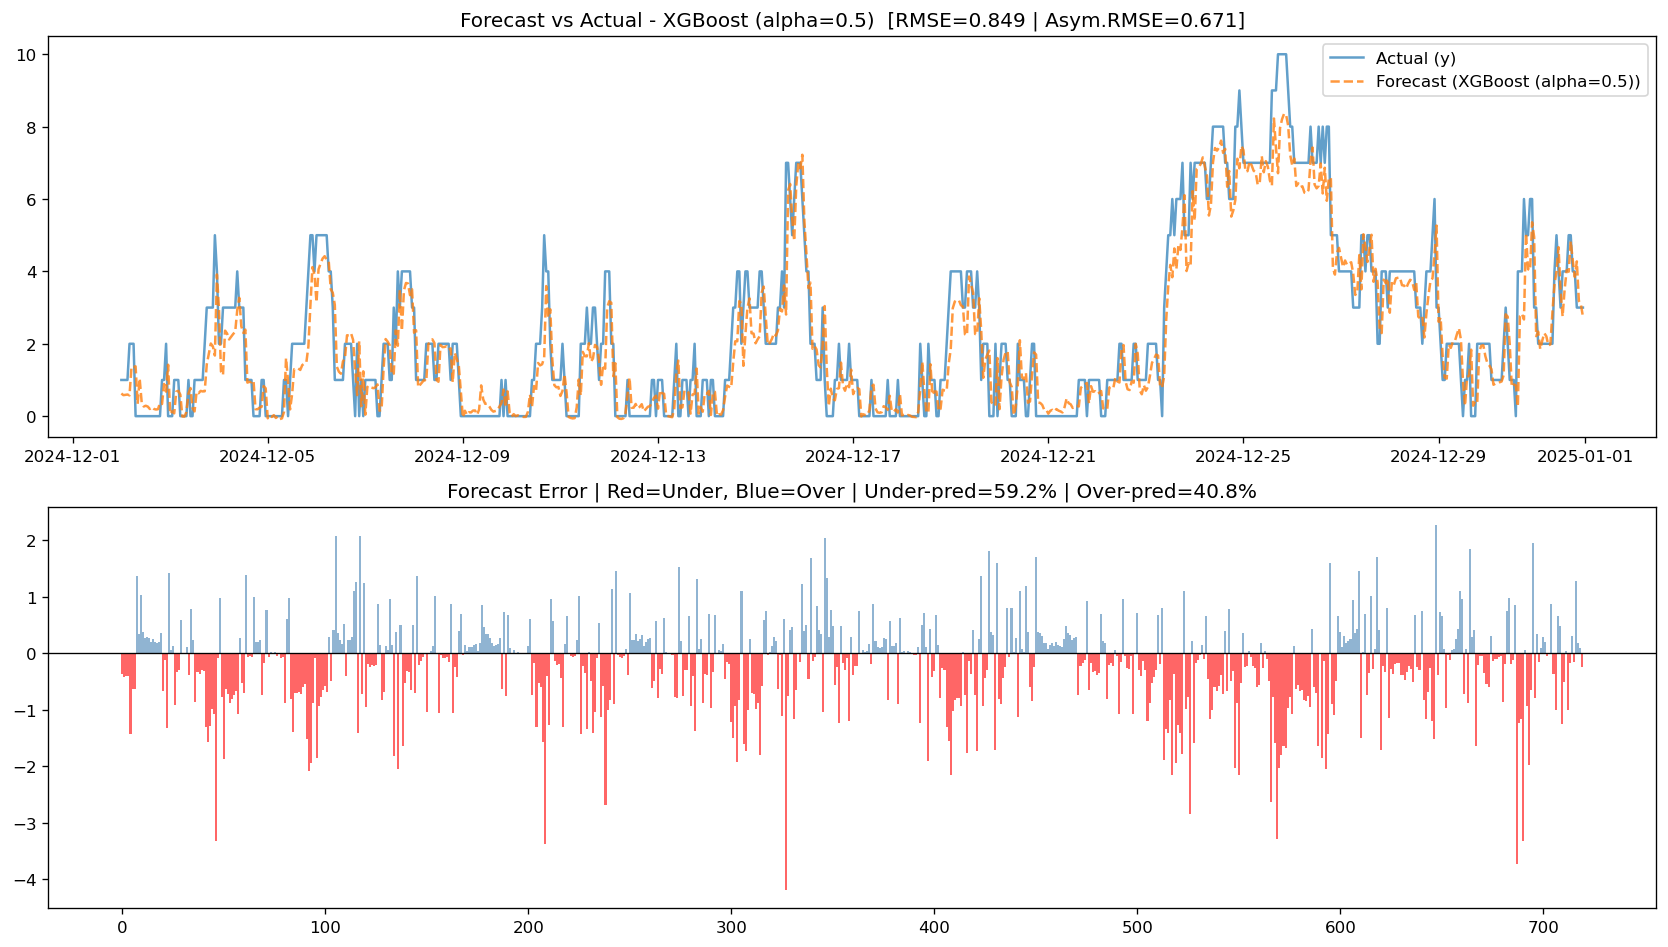

[XGBoost (alpha=0.3)]
  RMSE            : 0.893
  MAE             : 0.644
  Asymmetric RMSE : 0.579  (alpha=0.3)
  Under-pred rate : 61.5%
  Over-pred rate : 38.5%


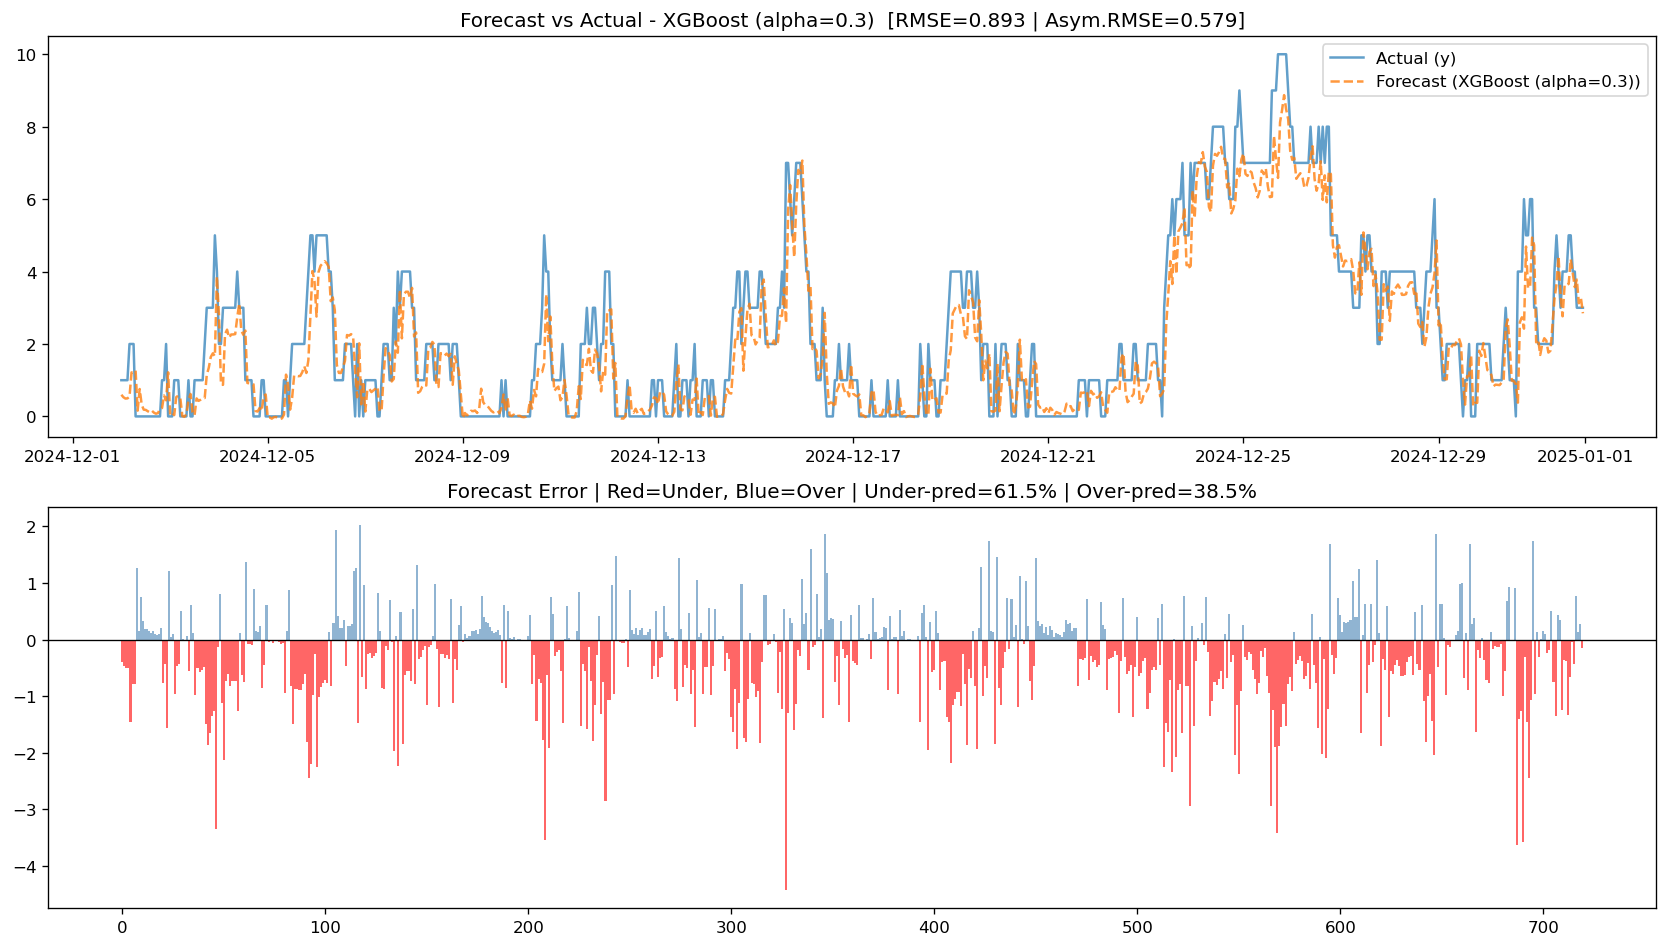

[XGBoost (alpha=0.2)]
  RMSE            : 0.926
  MAE             : 0.668
  Asymmetric RMSE : 0.515  (alpha=0.2)
  Under-pred rate : 61.7%
  Over-pred rate : 38.3%


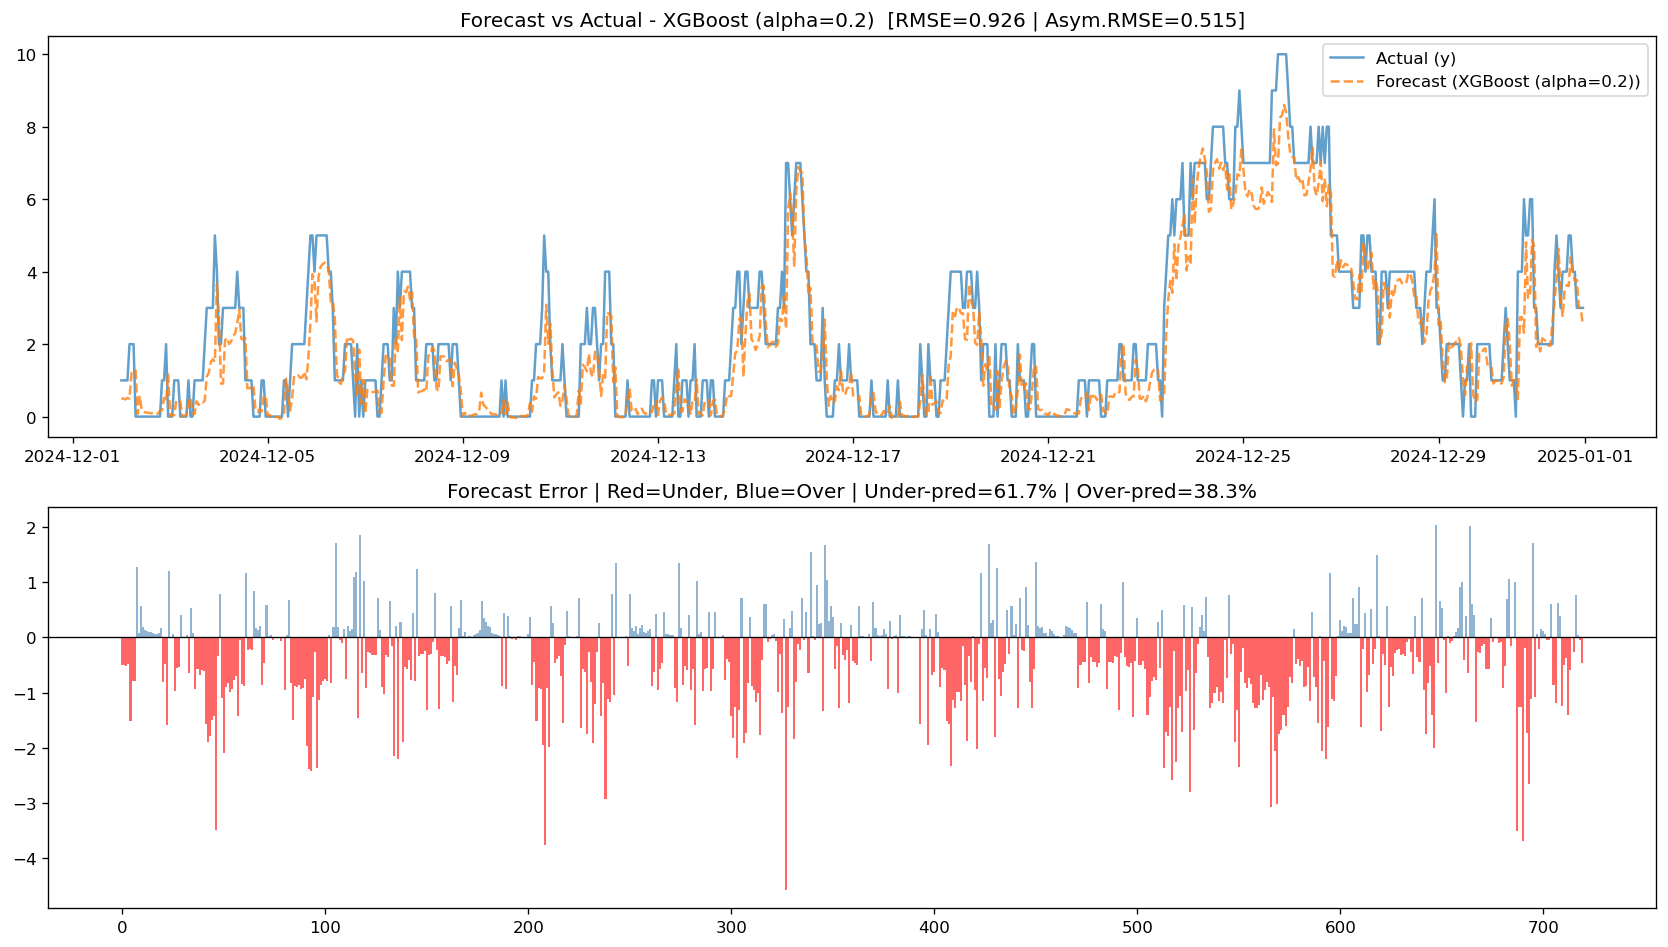

In [17]:
for alpha in [0.5, 0.3, 0.2]:
    xgb_asym_model = xgb.train(
        params=params,
        dtrain=dtrain,
        num_boost_round=300,
        obj=lambda y_pred, dtrain: asymmetric_obj(y_pred, dtrain, alpha=alpha),
        verbose_eval=False,
    )
    y_pred = xgb_asym_model.predict(dtest)
    perf = evaluate_ml_forecast(y_test, y_pred,
                                model_name=f"XGBoost (alpha={alpha})",
                                alpha=alpha)

    if alpha == 0.5:
        perf_xgb_asym = perf # alpha = 0.5 결과를 대표값으로 저장

## 8. Model Comparison (SARIMA / ARIMAX / RF / XGBoost)


              Model Performance Comparison
                      RMSE    MAE  Asym.RMSE(alpha=0.5)  Under-pred rate(%)  Over-pred rate(%)
model                                                                                         
SARIMA               0.000  0.000                 0.000                 0.0                0.0
ARIMAX               0.000  0.000                 0.000                 0.0                0.0
Random Forest        0.779  0.544                 0.664                46.8               53.2
XGBoost              0.818  0.595                 0.682                51.8               48.2
XGBoost (alpha=0.5)  0.849  0.609                 0.671                59.2               40.8


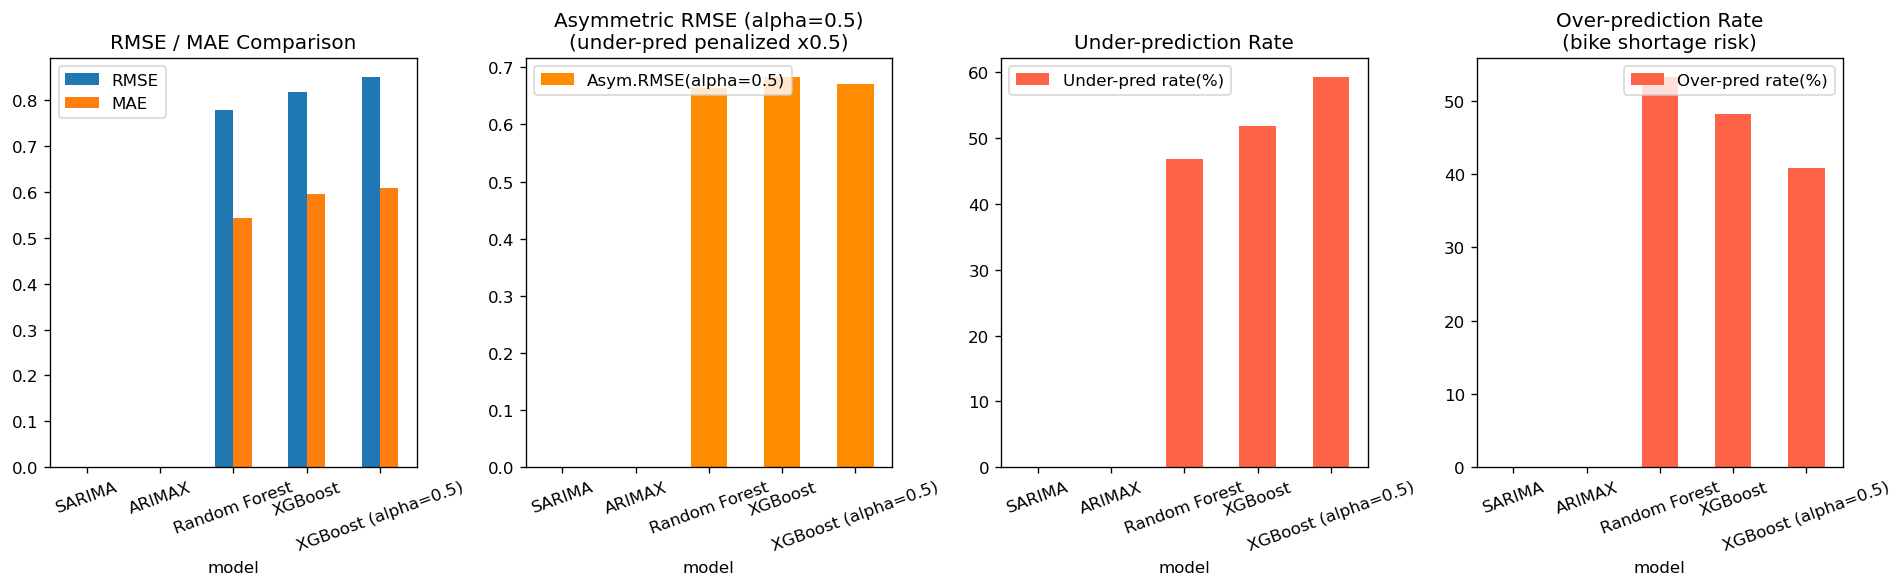

In [18]:
# 04, 05 파일 결과 보고 비교 - 임의로 결과 집어넣어놨음
SARIMA_RESULTS = {
    "RMSE": 0.0,
    "MAE": 0.0,
    "Asym.RMSE": 0.0,
    "Under-pred rate(%)": 0.0,
    "Over-pred rate(%)": 0.0
}
ARIMAX_RESULTS = {
    "RMSE": 0.0,
    "MAE": 0.0,
    "Asym.RMSE": 0.0,
    "Under-pred rate(%)": 0.0,
    "Over-pred rate(%)": 0.0
}

# Collect all results
all_results = []

# SARIMA
all_results.append({
    "model": "SARIMA",
    "RMSE": SARIMA_RESULTS["RMSE"],
    "MAE": SARIMA_RESULTS["MAE"],
    f"Asym.RMSE(alpha={ALPHA})": SARIMA_RESULTS["Asym.RMSE"],
    "Under-pred rate(%)": SARIMA_RESULTS["Under-pred rate(%)"],
    "Over-pred rate(%)": SARIMA_RESULTS["Over-pred rate(%)"],
})

# ARIMAX
all_results.append({
    "model": "ARIMAX",
    "RMSE": ARIMAX_RESULTS["RMSE"],
    "MAE": ARIMAX_RESULTS["MAE"],
    f"Asym.RMSE(alpha={ALPHA})": ARIMAX_RESULTS["Asym.RMSE"],
    "Under-pred rate(%)": ARIMAX_RESULTS["Under-pred rate(%)"],
    "Over-pred rate(%)": ARIMAX_RESULTS["Over-pred rate(%)"],
})

# ML results
all_results.append(perf_rf)
all_results.append(perf_xgb)
if HAS_XGB:
    all_results.append(perf_xgb_asym)



result_df = pd.DataFrame(all_results).set_index("model")
print("\n" + "="*65)
print("              Model Performance Comparison")
print("="*65)
print(result_df.to_string())

# Visualization
asym_col = f"Asym.RMSE(alpha={ALPHA})"
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

result_df[["RMSE", "MAE"]].plot(kind="bar", ax=axes[0],
    title="RMSE / MAE Comparison", rot=20)

result_df[[asym_col]].plot(kind="bar", ax=axes[1],
    title=f"Asymmetric RMSE (alpha={ALPHA})\n(under-pred penalized x{ALPHA})",
    rot=20, color="darkorange")

result_df[["Under-pred rate(%)"]].plot(kind="bar", ax=axes[2],
    title="Under-prediction Rate",
    rot=20, color="tomato")

result_df[["Over-pred rate(%)"]].plot(kind="bar", ax=axes[3],
    title="Over-prediction Rate\n(bike shortage risk)",
    rot=20, color="tomato")
plt.tight_layout()
plt.show()